# Setup

Imports support JSON ingestion, regex parsing of engagement strings, tabular work in `pandas`, and emoji span listing via `emoji` without altering stored comment text.


In [47]:
import asyncio
from tqdm.asyncio import tqdm
import json
import os
import re
import time

import emoji
import matplotlib_inline.backend_inline  # noqa: F401 — must precede pyplot when MPLBACKEND is set (notebooks)
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
from langdetect import LangDetectException, detect, DetectorFactory

from pydantic import BaseModel, Field
from pydantic_ai import Agent
from typing import Literal


from IPython.display import display

In [4]:
import nest_asyncio
nest_asyncio.apply()

In [5]:
load_dotenv()

True

In [6]:
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.05)
# set_theme() prepends Arial to font.sans-serif, so setdefault() never applied; rebuild the stack
# so DejaVu Sans is preferred for Latin text and emoji-capable fonts are available as fallbacks.
_emoji_faces = ["DejaVu Sans", "Apple Color Emoji", "Segoe UI Emoji", "Noto Color Emoji"]
_seen = set()
_sans = []
for _name in _emoji_faces + list(plt.rcParams["font.sans-serif"]):
    if _name not in _seen:
        _seen.add(_name)
        _sans.append(_name)
plt.rcParams["font.sans-serif"] = _sans

## Phase 1: Structural cleaning

Rows without usable text in `comment` are dropped. `likes` is cast to integer counts, `date_iso` to UTC datetimes, and `hash_id` is unique. The working frame is `df` with columns `case`, `username`, `comment`, `likes_raw`, `likes`, `date_iso`, and `hash_id`.


In [7]:
cr7_path = "data/CR7_Cmw4CjNrctl_comments.json"
bruno_mars_path = "data/Bruno_Mars_DCFD_ZoyZwa_comments.json"
fernanda_torres_path = "data/OSCAR_DChnVHMxyBD_comments.json"

CASE_BY_PATH = {
    cr7_path: "CR7",
    bruno_mars_path: "Bruno_Mars",
    fernanda_torres_path: "Fernanda_Torres",
}


def load_comments_json(path: str) -> pd.DataFrame:
    case = CASE_BY_PATH[str(path)]
    with open(path, encoding="utf-8") as f:
        rows = json.load(f)
    out = pd.DataFrame(rows)
    out.insert(0, "case", case)
    return out


def likes_to_int(raw) -> int:
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return 0
    m = re.match(r"^(\d+)", str(raw).strip())
    return int(m.group(1)) if m else 0


paths = [cr7_path, bruno_mars_path, fernanda_torres_path]
df = pd.concat([load_comments_json(p) for p in paths], ignore_index=True)
df = df.rename(columns={"likes": "likes_raw"})
df["likes"] = df["likes_raw"].map(likes_to_int)
df["date_iso"] = pd.to_datetime(df["date_iso"], utc=True, errors="coerce")
for col in ("username", "comment", "hash_id"):
    df[col] = df[col].astype("string")

df = df[["case", "username", "comment", "likes_raw", "likes", "date_iso", "hash_id"]]
# Earliest raw timestamp per case (includes empty OP rows dropped next) ≈ post / publish anchor.
PUBLISH_ANCHOR_UTC = df.groupby("case", observed=True)["date_iso"].min()
df = df.loc[df["comment"].notna() & df["comment"].str.strip().ne("")].reset_index(drop=True)
df["likes"] = df["likes"].astype("int64")
df["date_iso"] = pd.to_datetime(df["date_iso"], utc=True)
df = df.drop_duplicates(subset=["hash_id"], keep="first").reset_index(drop=True)
assert df["hash_id"].is_unique

print(f"Phase 1: {len(df):,} rows")


Phase 1: 17,287 rows


## Phase 2: Text normalization

`comment_norm` applies strip and case folding to `comment` for literal search and counting; the source column is unchanged.


In [8]:
df["comment_norm"] = df["comment"].str.strip().str.lower()


## Phase 3: Metadata extraction

`comment_length` is the character count of `comment`. `emojis_list` holds distinct emoji graphemes in first-appearance order; `hashtags_list` holds hashtag tokens, each including the leading `#`.


In [9]:
HASHTAG = re.compile(r"#[\w\u00c0-\u024f]+", flags=re.UNICODE)

df["comment_length"] = df["comment"].str.len()
df["emojis_list"] = df["comment"].map(lambda t: emoji.distinct_emoji_list(str(t)))
df["hashtags_list"] = df["comment"].map(HASHTAG.findall)

# Calendar days since per-case post anchor (see Phase 1: PUBLISH_ANCHOR_UTC).
_pub = df["case"].map(PUBLISH_ANCHOR_UTC)
df["days_old"] = (
    (df["date_iso"].dt.normalize() - _pub.dt.normalize()).dt.days.astype("Int64")
)


In [10]:
df.sample(10)

,case,username,comment,likes_raw,likes,date_iso,hash_id,comment_norm,comment_length,emojis_list,hashtags_list,days_old
6413,Bruno_Mars,dorgeania,❤️🇧🇷,1 Me gusta,1,2025-11-24 15:25:24+00:00,433c4f8314dc40e5358d34e83cefbb2c60d4f053240b15...,❤️🇧🇷,4,"[🇧🇷, ❤️]",[],382
12426,Fernanda_Torres,cacahborges,🇧🇷🇧🇷🇧🇷,1 Me gusta,1,2025-10-04 18:47:40+00:00,8088bc3c6caf2c8e13074688b644387bea3a5edf77b6f9...,🇧🇷🇧🇷🇧🇷,6,[🇧🇷],[],320
2355,CR7,youssef_elsady_,❤️,0,0,2023-01-02 02:01:42+00:00,f447ec5f64cabd9eba5f48719f8f3d8691461727eb9c5f...,❤️,2,[❤️],[],4
17234,Fernanda_Torres,larissavasconcellos_studio,😍😍😍😍😍,1 Me gusta,1,2025-01-27 03:34:15+00:00,df865ee1e4f1c6b247117ab9b9b30bd632a1e578896540...,😍😍😍😍😍,5,[😍],[],70
2498,CR7,damas_official1,"2 G. O. T when mets,R. I. P Pelè😢",0,0,2023-01-02 13:44:48+00:00,d9f749c4e1804e5fe1a926c68ebc31d095ad2f0494ff12...,"2 g. o. t when mets,r. i. p pelè😢",33,[😢],[],4
8525,Bruno_Mars,bernadete.bomfim.16,💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛,3 Me gusta,3,2025-12-19 13:15:02+00:00,53812aa4eeceae9041f64185783a8e386675798d19876a...,💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛💚💛,22,"[💚, 💛]",[],407
16902,Fernanda_Torres,bernardes.helen,🇧🇷,1 Me gusta,1,2025-01-25 22:56:40+00:00,5dc311b955e1da3019ab78b568318d373dbeab90fcaa13...,🇧🇷,2,[🇧🇷],[],68
3312,Bruno_Mars,dorgeania,🇧🇷💛,2 Me gusta,2,2026-02-11 10:35:22+00:00,34e9632e6e77809157e4c9c29e67a03672aca5d24bbb33...,🇧🇷💛,3,"[🇧🇷, 💛]",[],461
6325,Bruno_Mars,dorgeania,❤️🇧🇷💚,1 Me gusta,1,2025-11-22 20:05:37+00:00,3b802ce1175c1926f683d7ddad539df71c761aadb3242c...,❤️🇧🇷💚,5,"[💚, 🇧🇷, ❤️]",[],380
12816,Fernanda_Torres,the_memory_army,🇧🇷🇧🇷🇧🇷,1 Me gusta,1,2025-10-13 11:16:50+00:00,31009b4be722f3b1a9bd41669575d3aca75a986f5fa6b6...,🇧🇷🇧🇷🇧🇷,6,[🇧🇷],[],329


# Exploratory data analysis

This section documents aggregate behavior across the three case strata before thematic filtering: repetition in surface text, concentration of posting among users, non-verbal markers, calendar-level activity, and post-relative timing (`days_old`). All figures use a single Seaborn theme for comparable styling.

### 1. General distributions (engagement and length)

Histograms of `comment_length` are compared by `case` (with a high-percentile cap so the bulk of the mass is visible). Boxplots summarize `likes` by `case` on a log10(likes + 1) scale to accommodate skew and zeros.

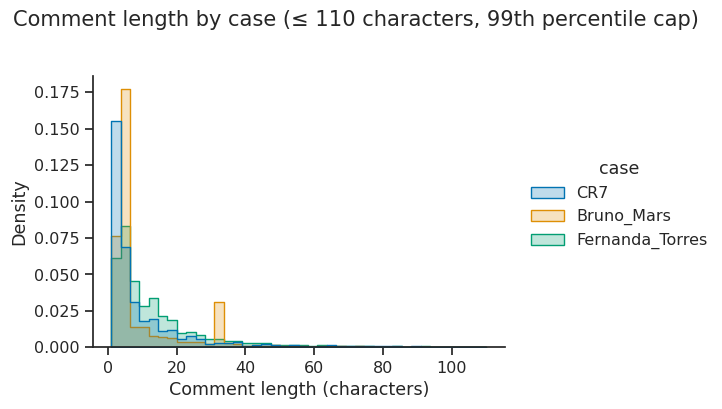

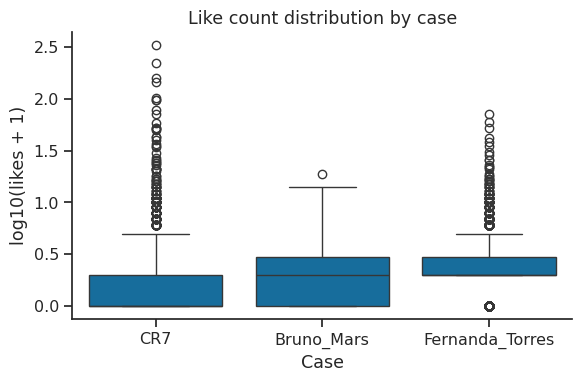

In [11]:
# --- 1. Comment length by case (99th percentile cap) ---
_cl_p99 = float(df["comment_length"].quantile(0.99))
_len_plot = df.loc[df["comment_length"] <= _cl_p99]
_g1 = sns.displot(
    data=_len_plot,
    x="comment_length",
    hue="case",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    bins=40,
    height=4,
    aspect=1.35,
)
_g1.set_axis_labels("Comment length (characters)", "Density")
_g1.figure.suptitle(
    f"Comment length by case (≤ {_cl_p99:.0f} characters, 99th percentile cap)",
    y=1.02,
)
_g1.tight_layout()

# --- 1b. Likes by case (log-scaled) ---
_df_likes = df.assign(log_likes=np.log10(df["likes"].to_numpy(dtype=float) + 1.0))
_fig, _ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=_df_likes, x="case", y="log_likes", ax=_ax)
_ax.set_ylabel("log10(likes + 1)")
_ax.set_xlabel("Case")
_ax.set_title("Like count distribution by case")
sns.despine(ax=_ax)
_fig.tight_layout()

### 2. User activity and concentration

The global frequency of comments per `username` is ranked; the twenty largest counts are shown as a horizontal bar chart to evidence uneven participation across accounts.

Largest single-account volume: dorgeania (4548 comments)


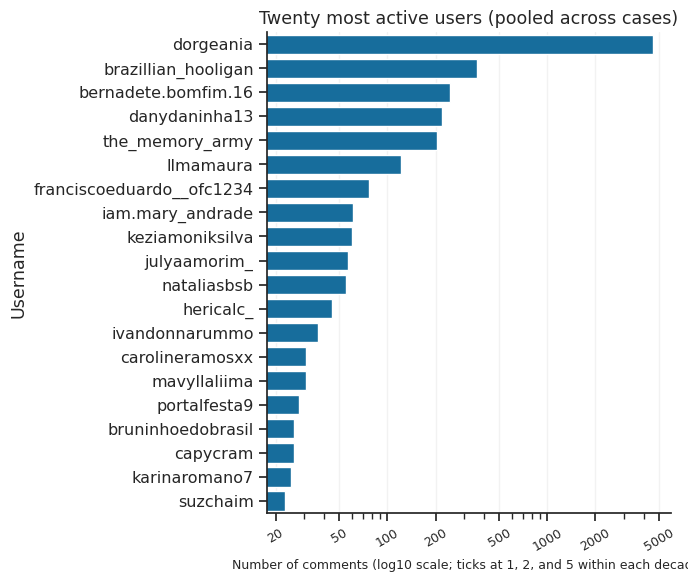

In [12]:
# --- 2. Top 20 users by comment count ---
_top_users = (
    df.groupby("username", observed=True)
    .size()
    .nlargest(20)
    .reset_index(name="count")
)
_fig2, _ax2 = plt.subplots(figsize=(7, 6))
sns.barplot(
    data=_top_users,
    y="username",
    x="count",
    orient="h",
    ax=_ax2,
    color=sns.color_palette()[0],
)
import matplotlib.ticker as mticker

_ax2.set_xscale("log", base=10)
_ax2.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
_ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(round(x))}" if x >= 1 else "")
)
_ax2.tick_params(axis="x", labelsize=9, rotation=30)
_ax2.set_xlabel(
    "Number of comments (log10 scale; ticks at 1, 2, and 5 within each decade)",
    fontsize=9,
)
_ax2.set_ylabel("Username")
_ax2.set_title("Twenty most active users (pooled across cases)")
_ax2.grid(True, axis="x", which="major", alpha=0.25)
sns.despine(ax=_ax2)
_fig2.tight_layout()
print(
    f"Largest single-account volume: {_top_users.iloc[0]['username']} "
    f"({_top_users.iloc[0]['count']:.0f} comments)"
)


### 3. Content repetition (normalized text)

Exact-string repetition is summarized on `comment_norm`: the fifteen largest frequencies are tabulated and plotted with truncated labels for readability.

,comment_norm,count
0,@bruninhoedobrasil #rumoaos200m,599
1,🇧🇷,461
2,❤️,427
3,🇧🇷🇧🇷🇧🇷,292
4,🇧🇷🇧🇷🇧🇷🇧🇷,232
5,❤️❤️❤️,207
6,🇧🇷❤️,191
7,🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷,170
8,😍,168
9,🔥,135


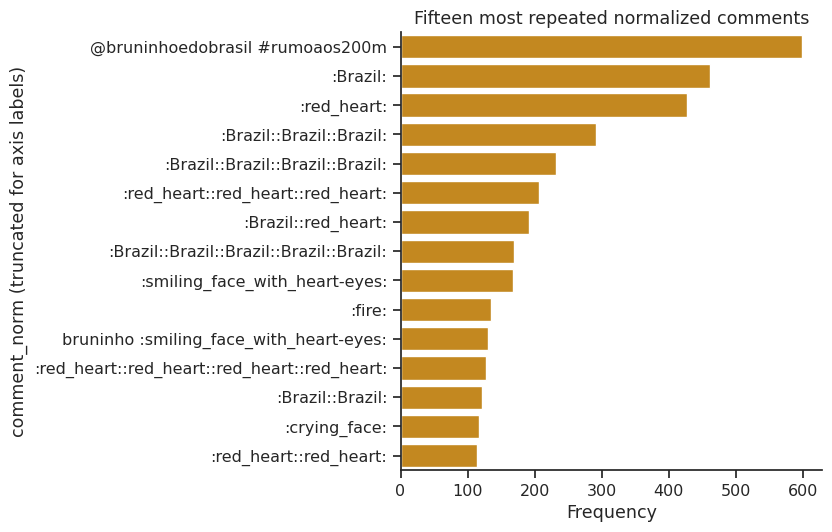

In [60]:
# --- 3. Most frequent normalized comments ---
_rep = (
    df.groupby("comment_norm", observed=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="count")
)
display(_rep)
_rep_vis = _rep.assign(
    label=_rep["comment_norm"].str.slice(0, 45).map(lambda s: emoji.demojize(str(s))),
)
_fig, _ax = plt.subplots(figsize=(8.5, 5.5))
sns.barplot(
    data=_rep_vis,
    y="label",
    x="count",
    orient="h",
    ax=_ax,
    color=sns.color_palette()[1],
)
_ax.set_xlabel("Frequency")
_ax.set_ylabel("comment_norm (truncated for axis labels)")
_ax.set_title("Fifteen most repeated normalized comments")
sns.despine(ax=_ax)
_fig.tight_layout()

### 4. Visual and cultural markers

`emojis_list` and `hashtags_list` are exploded and counted within each `case`; the ten most frequent tokens per case are shown as faceted bar charts (hashtags retain the leading `#`).

In [14]:
# --- Global emoji top 20 ---
_em_all = df.explode("emojis_list").dropna(subset=["emojis_list"])
_em_all = _em_all.loc[_em_all["emojis_list"].astype(str).str.len() > 0]
global_emoji_counts = _em_all["emojis_list"].value_counts().head(20).reset_index()
global_emoji_counts.columns = ["emojis_list", "count"]
global_emoji_counts["emoji_plot"] = global_emoji_counts["emojis_list"].apply(lambda x: emoji.demojize(str(x)))
print("Global top 20 emojis:")
display(global_emoji_counts)

# --- Global hashtag top 20 ---
_ht_all = df.explode("hashtags_list").dropna(subset=["hashtags_list"])
_ht_all = _ht_all.loc[_ht_all["hashtags_list"].astype(str).str.len() > 0]
_ht_tag_vc = _ht_all["hashtags_list"].value_counts()
global_hashtag_top20 = _ht_tag_vc.head(20).reset_index()
global_hashtag_top20.columns = ["hashtags_list", "count"]
global_hashtag_outliers = global_hashtag_top20.head(2).copy()
global_hashtag_counts_plot = global_hashtag_top20.iloc[2:].copy()

print("Global top 20 hashtags:")
display(global_hashtag_top20)
print(
    "\nThe two most frequent hashtags (rows 1–2 above) are extreme outliers; "
    "they are omitted from the right-hand bar chart so ranks 3–20 stay readable. "
    "Their counts are repeated in the plot footnote."
)


Global top 20 emojis:


,emojis_list,count,emoji_plot
0,🇧🇷,9358,:Brazil:
1,❤️,4241,:red_heart:
2,😍,2214,:smiling_face_with_heart-eyes:
3,💚,2049,:green_heart:
4,🔥,1924,:fire:
5,💛,1568,:yellow_heart:
6,🏆,1531,:trophy:
7,📍,1275,:round_pushpin:
8,😂,1080,:face_with_tears_of_joy:
9,👏,1043,:clapping_hands:


Global top 20 hashtags:


,hashtags_list,count
0,#rumoaos200m,376
1,#rumoaos200M,236
2,#imstillhere,14
3,#aindaestouaqui,12
4,#fernandatorres,10
5,#theperamesedsavior,5
6,#200M,3
7,#ImStillHere,3
8,#oscars,2
9,#oscar2025,2



The two most frequent hashtags (rows 1–2 above) are extreme outliers; they are omitted from the right-hand bar chart so ranks 3–20 stay readable. Their counts are repeated in the plot footnote.


Text(0.5, 0.01, 'Outliers (full counts, omitted from bars): #rumoaos200m = 376  |  #rumoaos200M = 236')

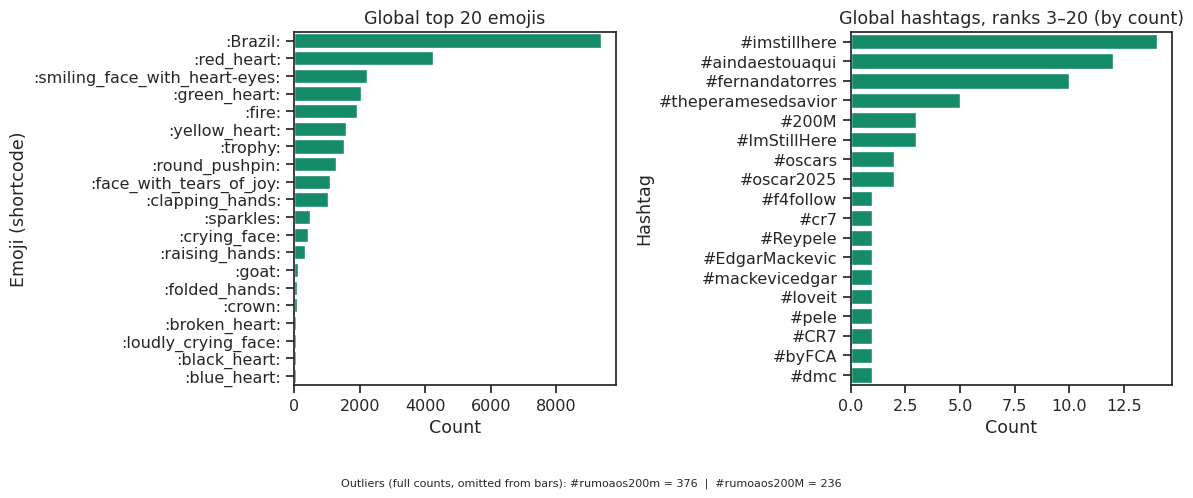

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=global_emoji_counts, y="emoji_plot", x="count", ax=axes[0], color=sns.color_palette()[2])
axes[0].set_title("Global top 20 emojis")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Emoji (shortcode)")

sns.barplot(
    data=global_hashtag_counts_plot,
    y="hashtags_list",
    x="count",
    ax=axes[1],
    color=sns.color_palette()[2],
)
axes[1].set_title("Global hashtags, ranks 3–20 (by count)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Hashtag")
_o1, _o2 = global_hashtag_outliers.iloc[0], global_hashtag_outliers.iloc[1]
_ht_note = (
    f"Outliers (full counts, omitted from bars): {_o1['hashtags_list']} = {_o1['count']:,}  |  "
    f"{_o2['hashtags_list']} = {_o2['count']:,}"
)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.01, _ht_note, ha="center", fontsize=8)


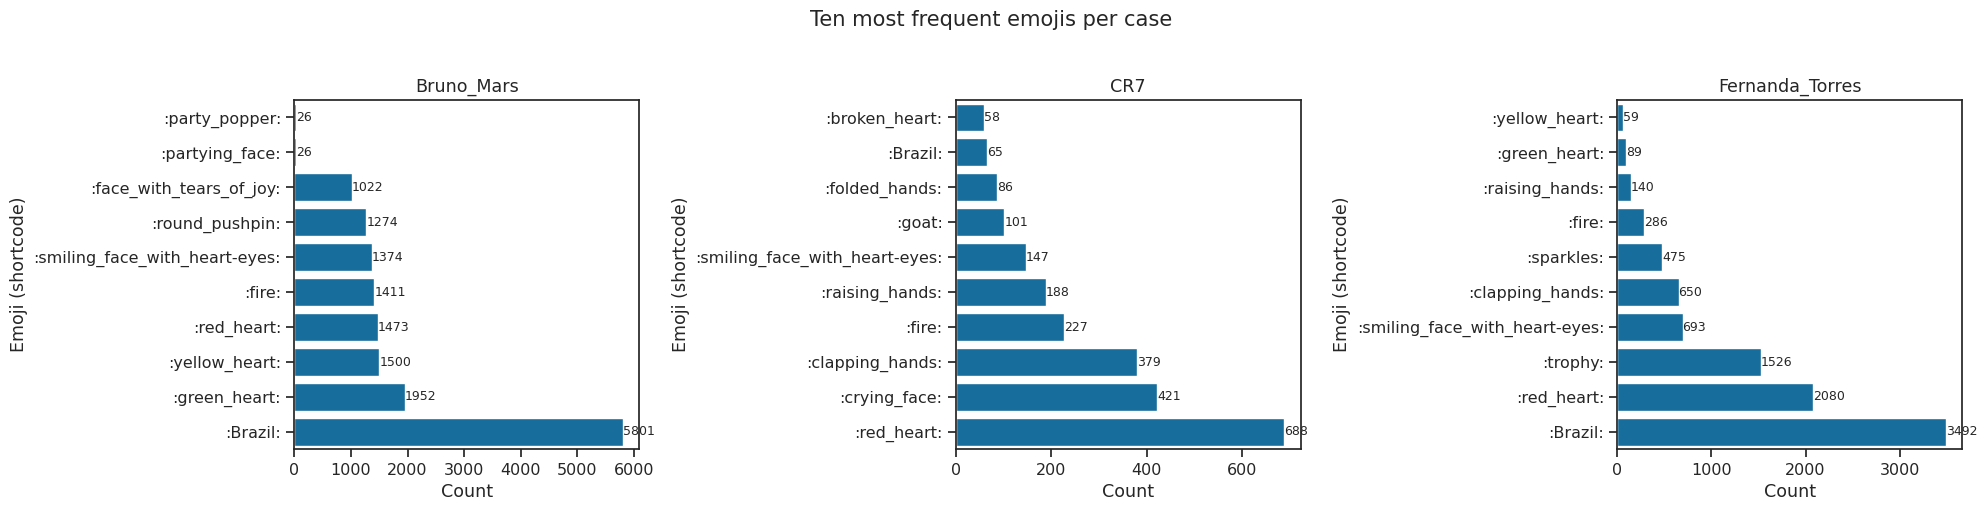

In [16]:
# Prepare data with sorting inside each case
_em = df.explode("emojis_list").dropna(subset=["emojis_list"])
_em = _em.loc[_em["emojis_list"].astype(str).str.len() > 0]
_emo_n = _em.groupby(["case", "emojis_list"], observed=True).size().reset_index(name="n")
# Sort within each case and take top 10
_emo_top = (
    _emo_n.sort_values(["case", "n"], ascending=[True, False])
    .groupby("case", observed=True)
    .head(10)
    .assign(emoji_shortcode=lambda d: d["emojis_list"].astype(str).map(emoji.demojize))
)

# Create a figure with two subplots (one for each case)
cases = _emo_top["case"].unique()
fig, axes = plt.subplots(1, len(cases), figsize=(20, 5), sharex=False, sharey=False)
if len(cases) == 1:
    axes = [axes]

for ax, case in zip(axes, cases):
    data_case = _emo_top[_emo_top["case"] == case].sort_values("n", ascending=True)  # ascending for horizontal bar
    sns.barplot(data=data_case, y="emoji_shortcode", x="n", ax=ax, color=sns.color_palette()[0])
    ax.set_title(case)
    ax.set_xlabel("Count")
    ax.set_ylabel("Emoji (shortcode)")
    # Add count labels at the end of bars
    for i, (_, row) in enumerate(data_case.iterrows()):
        ax.text(row["n"] + 0.3, i, str(row["n"]), va="center", fontsize=9)
fig.suptitle("Ten most frequent emojis per case", y=1.02)
fig.tight_layout()

In [17]:
stats = []
for case in df["case"].unique():
    case_df = df[df["case"] == case]
    emojis_in_case = case_df["emojis_list"].explode().dropna()
    hashtags_in_case = case_df["hashtags_list"].explode().dropna()
    stats.append({
        "Case": case,
        "Total comments": len(case_df),
        "Unique emojis": emojis_in_case.nunique(),
        "Total emoji occurrences": len(emojis_in_case),
        "Unique hashtags": hashtags_in_case.nunique(),
        "Total hashtag occurrences": len(hashtags_in_case),
    })
stats_df = pd.DataFrame(stats)
print("Global summary statistics per case:")
display(stats_df)

Global summary statistics per case:


,Case,Total comments,Unique emojis,Total emoji occurrences,Unique hashtags,Total hashtag occurrences
0,CR7,2568,225,3048,18,22
1,Bruno_Mars,8100,133,16232,13,625
2,Fernanda_Torres,6619,152,9942,27,64


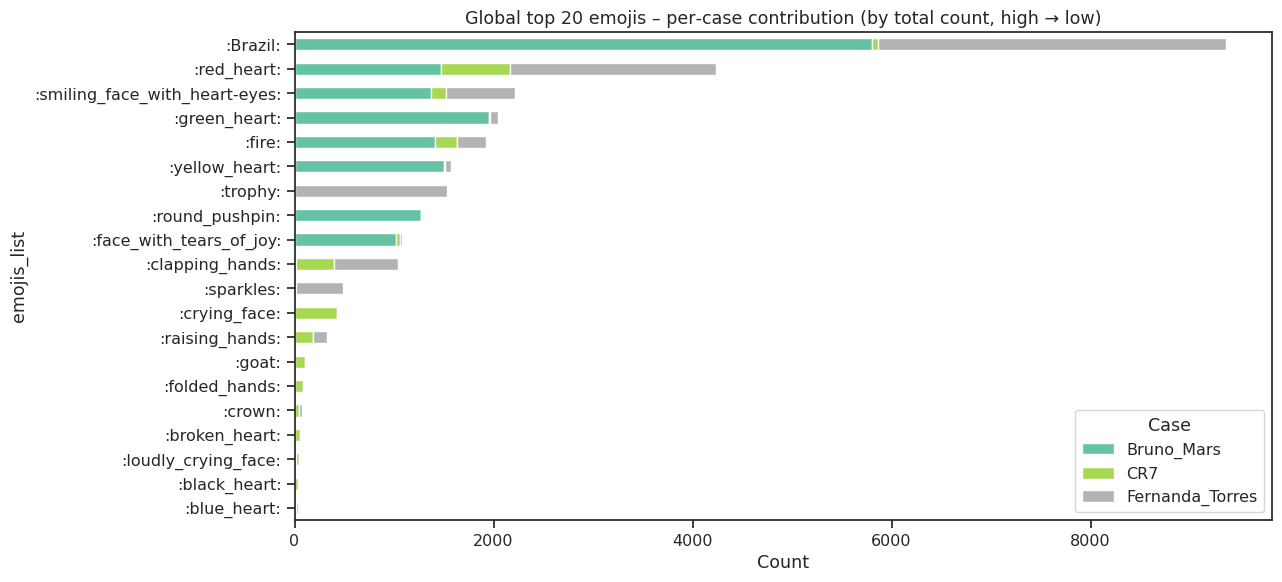

In [18]:
# Get global top 20 emojis (order only matters for display after pivot; isin ignores order)
top_global_emojis = global_emoji_counts["emojis_list"].head(20).tolist()

# Filter original exploded data to only those emojis, then count per case
_em_filtered = _em[_em["emojis_list"].isin(top_global_emojis)]
case_breakdown = _em_filtered.groupby(["emojis_list", "case"]).size().reset_index(name="count")
# Pivot for plotting
pivot_breakdown = case_breakdown.pivot(index="emojis_list", columns="case", values="count").fillna(0)
# Replace index with shortcodes for plotting
pivot_breakdown.index = pivot_breakdown.index.map(lambda x: emoji.demojize(str(x)))
# barh: first row is drawn at the bottom — sort ascending by total so highest count is at the top
_row_totals = pivot_breakdown.sum(axis=1)
pivot_breakdown = pivot_breakdown.loc[_row_totals.sort_values(ascending=True).index]

# Plot stacked bars
pivot_breakdown.plot(kind="barh", stacked=True, figsize=(13, 6), colormap="Set2")
plt.xlabel("Count")
plt.title("Global top 20 emojis – per‑case contribution (by total count, high → low)")
plt.legend(title="Case", loc="lower right")
plt.tight_layout()

### 5. Temporal analysis

Three coordinated views use UTC timestamps and `days_old` (calendar days since the per-case anchor from Phase 1). **(a)** Daily counts use `pd.Grouper(freq='D')` and a **seven-day rolling mean** to damp single-day noise. **(b)** The **empirical CDF** of `days_old` compares how each corpus accumulates over time after the anchor. **(c)** **Median** `log10(likes + 1)` in **30-day** age bins summarizes how typical engagement shifts as threads age.

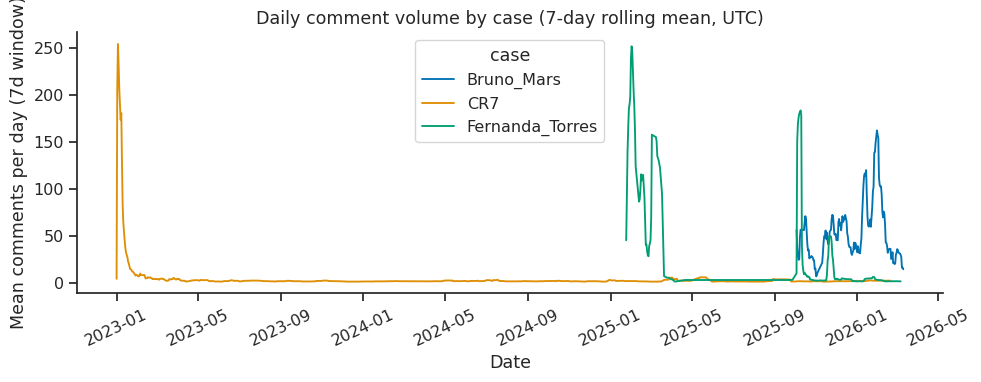

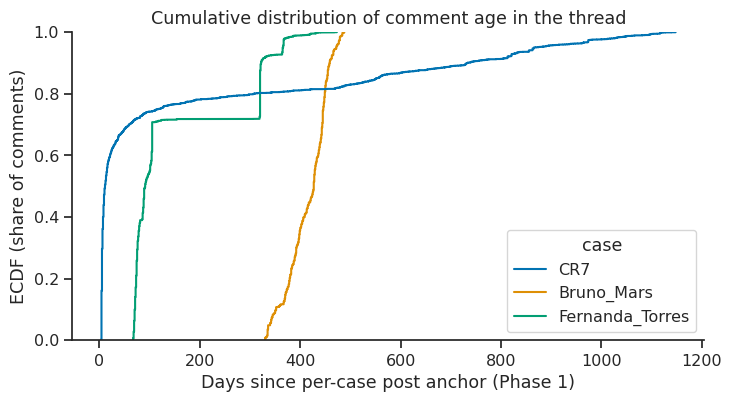

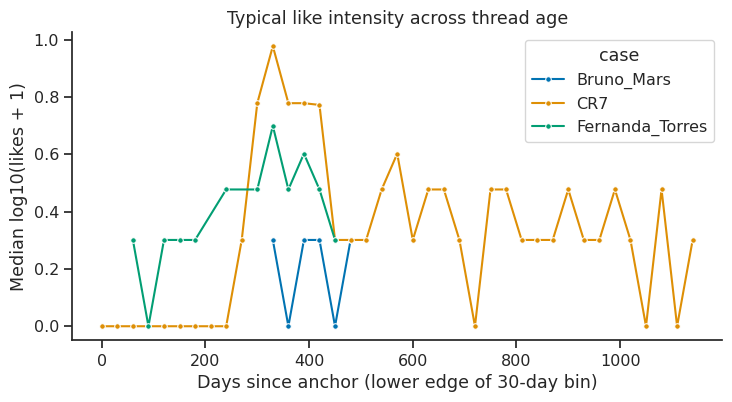

In [19]:
# --- 5a. Smoothed daily comment volume (UTC, 7-day rolling mean) ---
_daily = (
    df.groupby(["case", pd.Grouper(key="date_iso", freq="D")], observed=True)
    .size()
    .reset_index(name="n_comments")
    .sort_values(["case", "date_iso"])
)
_daily["n_roll7"] = _daily.groupby("case", observed=True)["n_comments"].transform(
    lambda s: s.rolling(window=7, min_periods=1).mean()
)

_fig_a, _ax_a = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=_daily,
    x="date_iso",
    y="n_roll7",
    hue="case",
    ax=_ax_a,
    linewidth=1.35,
)
_ax_a.set_title("Daily comment volume by case (7-day rolling mean, UTC)")
_ax_a.set_xlabel("Date")
_ax_a.set_ylabel("Mean comments per day (7d window)")
_ax_a.tick_params(axis="x", rotation=25)
sns.despine(ax=_ax_a)
_fig_a.tight_layout()

# --- 5b. ECDF of post-relative age (days_old) by case ---
_df_age = df.dropna(subset=["days_old"]).copy()
_df_age["days_old"] = _df_age["days_old"].astype(int)

_fig_b, _ax_b = plt.subplots(figsize=(7.5, 4.2))
sns.ecdfplot(data=_df_age, x="days_old", hue="case", ax=_ax_b)
_ax_b.set_xlabel("Days since per-case post anchor (Phase 1)")
_ax_b.set_ylabel("ECDF (share of comments)")
_ax_b.set_title("Cumulative distribution of comment age in the thread")
sns.despine(ax=_ax_b)
_fig_b.tight_layout()

# --- 5c. Median log-likes by 30-day age bins ---
_tmp = _df_age.assign(
    age_bin=(_df_age["days_old"] // 30).astype(int) * 30,
    log_likes=np.log10(_df_age["likes"].to_numpy(dtype=float) + 1.0),
)
_like_age = (
    _tmp.groupby(["case", "age_bin"], observed=True)["log_likes"]
    .median()
    .reset_index()
)

_fig_c, _ax_c = plt.subplots(figsize=(7.5, 4.2))
sns.lineplot(
    data=_like_age,
    x="age_bin",
    y="log_likes",
    hue="case",
    marker="o",
    markersize=4,
    ax=_ax_c,
)
_ax_c.set_xlabel("Days since anchor (lower edge of 30-day bin)")
_ax_c.set_ylabel("Median log10(likes + 1)")
_ax_c.set_title("Typical like intensity across thread age")
sns.despine(ax=_ax_c)
_fig_c.tight_layout()


# NLP Processing

## 1. is_brazilian Composite Metric

 To rigorously investigate the digital behavior of Brazilians, we must establish an inclusion criterion that accounts for the fluid nature of digital interactions. A single language-detection algorithm is insufficient, as digital participation often involves micro-texts, emojis, or foreign languages (e.g., "Come to Brazil").  According to the methodology, a comment is included if it meets at least one of three distinct dimensions: linguistic markers , authorship profile , or the presence of unequivocal cultural "digital traces". The is_brazilian metric is a composite Boolean filter (True/False) resulting from the logical OR combination of three algorithmic tests. 

In [20]:
## 2. Ensure consistent results for langdetect

DetectorFactory.seed = 42

def detect_comment_language(text, min_length=10):
    """ISO 639-1 code from langdetect, or ``pd.NA`` when skipped or undetectable."""
    if pd.isna(text) or len(str(text)) < min_length:
        return pd.NA
    try:
        return detect(str(text))
    except LangDetectException:
        return pd.NA


def detect_portuguese(text, min_length=10):
    """
    Test 1: Linguistic Marker.
    Uses langdetect to identify Portuguese. Skipped for very short texts
    to avoid false positives with emojis or acronyms.
    """
    lang = detect_comment_language(text, min_length=min_length)
    return pd.notna(lang) and lang == "pt"

def check_username_markers(username):
    """
    Test 2: Authorship Marker.
    Uses enhanced regex and a curated list of Brazilian‑specific names/nicknames.
    """
    if pd.isna(username):
        return False
    username = str(username).lower()

    # 1. Regex patterns typical of Brazilian accounts
    pattern_br_indicators = (
        r"(_br$|\.br$|^br[_.-]|_ofc$|_fc$|brs$|"
        r"^x[_.-]?br[_.-]?x$|"               # xX_br_Xx style
        r"^br[0-9]+$|"                       # br123
        r"(^|_)brasil($|_)|"                 # _brasil_ or brasil_
        r"_zinho$|_zinha$|_?[0-9]+(inho|inha)$"  # luizinho123
        r"corinthians|flamengo|palmeiras|santos|gremio|internacional|"
        r"cruzeiro|atletico|vasco|botafogo|fluminense|bahia|ceara|"
        r"fortaleza|sport|coritiba|athletico|goias|vitoria|"
        r"carioca|paulista|mineiro|gaucho|baiano|pernambucano|"
        r"soteropolitano|manauara|paraense|cearense|potiguar|"
        r"curitibano|florianopolitano|belenense|brasiliense)"
    )
    if re.search(pattern_br_indicators, username):
        return True

    # 2. Diminutives (Brazil loves them)
    pattern_diminutives = r"(inho|inha|zinho|zinha)([0-9_]*)$"
    if re.search(pattern_diminutives, username):
        return True

    # 3. Curated list of common Brazilian first names (avoiding generic ones)
    br_firstnames = {
        "enzo", "valentina", "arthur", "alice", "theo", "sofia", "davi", "beatriz",
        "gabriel", "manuela", "pedro", "julia", "lucas", "laura", "nicolas", "mariana",
        "rafael", "giovanna", "matheus", "cecilia", "gustavo", "isabella", "guilherme",
        "helena", "felipe", "lorena", "bernardo", "larissa", "caua", "leticia", "samuel",
        "clarice", "vitor", "melissa", "henrique", "rebeca", "joaquim", "luiza", "miguel",
        "bianca", "davi", "maysa", "breno", "lais", "ian", "evelyn", "raul", "viviane",
        "wesley", "jessica", "william", "karina", "bryan", "tatiane", "kaue", "thais"
    }
    # Check if username contains any of these names as a separate word or bound
    # We split on non-alphanumeric and check each part
    parts = re.split(r'[\W_]+', username)
    if any(part in br_firstnames for part in parts):
        return True

    # 4. Very common Brazilian surnames (still used, but less ambiguous when paired)
    # We keep them, but they are weaker alone. Still, useful as part of OR condition.
    br_surnames = {
        "silva", "santos", "oliveira", "souza", "rodrigues", "ferreira", "alves",
        "pereira", "lima", "gomes", "costa", "ribeiro", "martins", "carvalho",
        "almeida", "lopes", "soares", "fernandes", "vieira", "barbosa", "rocha",
        "dias", "nascimento", "andrade", "moreira", "nunes", "marques", "machado",
        "mendes", "freitas", "cardoso", "ramos", "goncalves", "santana", "teixeira"
    }
    if any(surname in parts for surname in br_surnames):
        return True

    return False


def check_cultural_trace(row):
    """
    Test 3: Cultural & Semantic Marker (The "Digital Trace").
    Improved to strongly prefer Brazilian markers and avoid Portugal Portuguese.
    """
    text = str(row.get('comment_norm', '')).lower()
    emojis = row.get('emojis_list', [])

    if pd.isna(text):
        text = ""

    # 1. Iconography Check (Emojis)
    if '🇧🇷' in emojis:
        return True
    # Brazilian flag colors combination is strong
    if '💚' in emojis and '💛' in emojis:
        return True

    # 2. Digital Laughter (Brazilian internet specific)
    pattern_laughter = (
        r"(k{4,}|rsrs|huehue|hausha|ushaush|skksks|kakaka|"
        r"hahaha|ahahah|kkk|kkkk|kkkkk|"
        r"askpoakpo|ahsuahsu|rssss|hehehe|hihihi|huhuhu|"
        r"ahahahaha|kkkkkk)"
    )
    if re.search(pattern_laughter, text):
        return True

    # 3. Brazilian slang & slogans (curated, avoiding Portugal-only terms)
    pattern_slang = r"""
        \b(
            # Direct Brazil mentions (often used by Brazilians talking to gringos)
            come\s+to\s+brazil|brazil\s+loves\s+you|
            # Football/sports
            hexa|penta|pel[eé]|neymar|vini\s*jr|realmadrid\s*brasil|
            # Brazilian TV/pop culture
            silvio\s+santos|xuxa|gugu|faust[ãa]o|bbb|tadeu\s*schmidt|
            # Interjections and slang
            vixe|oxe|mano|v[eé]i|slc|brabo|tropa|bonde|macetou|habla|
            entregou\s+tudo|é\s+o\s+brasa|gringo|gringos|n[oó]is|
            t[áa]\s+na\s+gringa|brasileiro|brasileira|
            # Common Brazilian exclamations
            caralho|porra|viado|merm[ãa]o|poha|mlk|bixo|doidera|par[çc]a|
            irm[aã]ozinho|trem|uai|bah|pampa|cacetinho|xis|gurizada|pi[áa]|
            # Food/culture
            churras|feijoada|caipirinha|samba|funk|favela|rolezinho|
            # Verbs and expressions
            ficar\s+de\s+paquera|tbt\s+saudades|deus\s+no\s+comando|
            gigante\s+pela\s+pr[óo]pria\s+natureza|amassou|chora\s+gringo|
            chupa\s+gringo
        )\b
    """
    if re.search(pattern_slang, text, re.VERBOSE | re.IGNORECASE):
        return True

    return False

def apply_is_brazilian_metric(df):
    """
    Wrapper function to apply the composite boolean metric to the entire DataFrame.
    """
    print("Detecting comment language (langdetect)...")
    df["language"] = (
        df["comment_norm"]
        .map(lambda t: detect_comment_language(t, min_length=10))
        .astype("string")
    )

    print("Applying linguistic markers...")
    test1 = df["language"].eq("pt").fillna(False)

    print("Applying authorship markers...")
    test2 = df['username'].apply(check_username_markers)

    print("Applying cultural trace markers...")
    test3 = df.apply(check_cultural_trace, axis=1)

    # Logical OR: If any of the tests pass, the comment is included
    df['is_brazilian'] = test1 | test2 | test3
    return df

### Execution

In [21]:
df = apply_is_brazilian_metric(df)

print(f"Comments classified as Brazilian: {df['is_brazilian'].sum()} out of {len(df)}")

Detecting comment language (langdetect)...


Applying linguistic markers...
Applying authorship markers...
Applying cultural trace markers...
Comments classified as Brazilian: 11706 out of 17287


## 2. Anonymization

Following the identification of the target population, to ensure ethical compliance in digital research, all data is anonymized , removing direct mentions (`@username`) and substituting original usernames with standardized internal IDs.


In [22]:
def create_final_df(df):
    """
    Applies anonymization for ethical compliance on the full dataset.
    No exclusion filters or top-N subsampling; every row in ``df`` is retained.
    """
    df_sample = df.copy()


    # Deterministic order within each case for reproducible methodological IDs
    df_sample = df_sample.sort_values(
        by=["case", "date_iso"],
        ascending=[True, True],
    ).reset_index(drop=True)

    # Redact @handles in comment text
    df_sample["comment_anon"] = df_sample["comment"].astype(str).apply(
        lambda x: re.sub(r"@[\w.]+", "@user", x)
    )

    df_sample["comment_number"] = df_sample.groupby("case", sort=False).cumcount() + 1
    _pad = max(4, len(str(int(df_sample.groupby("case").size().max()))))
    df_sample["hash_id"] = (
        df_sample["case"].astype(str).str.upper()
        + "_"
        + df_sample["comment_number"].map(lambda n: f"{int(n):0{_pad}d}")
    )

    columns_to_drop = ["username", "comment_number"]
    df_sample = df_sample.drop(columns=[c for c in columns_to_drop if c in df_sample.columns])

    return df_sample.reset_index(drop=True)


### Execution

In [23]:
df_final = create_final_df(df)

df_with_lang = df_final[df_final['language'] != "<NA>"]

ratios = df_with_lang['language'].value_counts() / len(df_with_lang)

print(f"Final dataset shape: {df_final.shape}")
print(f'Rate of comments with language: {len(df_with_lang) / len(df_final)}')
print(f"Language ratios: {ratios[:5]}")

print(f"Ratio of Brazilian comments: {df_final['is_brazilian'].mean()}")

display(df_with_lang.sample(10))

Final dataset shape: (17287, 14)
Rate of comments with language: 0.28165673627581417
Language ratios: language
pt    0.570754
en    0.128158
es      0.0458
so    0.037379
it    0.034093
Name: count, dtype: Float64
Ratio of Brazilian comments: 0.6771562445768496


,case,comment,likes_raw,likes,date_iso,hash_id,comment_norm,comment_length,emojis_list,hashtags_list,days_old,language,is_brazilian,comment_anon
14784,Fernanda_Torres,Fernanda 🏆🏆🏆🏆🏆,1 Me gusta,1,2025-03-03 00:29:51+00:00,FERNANDA_TORRES_4117,fernanda 🏆🏆🏆🏆🏆,14,[🏆],[],105,sv,False,Fernanda 🏆🏆🏆🏆🏆
8671,CR7,👏👏👏👏👏👏 you are the first,0,0,2023-01-03 13:30:40+00:00,CR7_0572,👏👏👏👏👏👏 you are the first,24,[👏],[],5,en,False,👏👏👏👏👏👏 you are the first
8618,CR7,Return to Ranaldo real,0,0,2023-01-03 09:16:11+00:00,CR7_0519,return to ranaldo real,22,[],[],5,en,False,Return to Ranaldo real
14454,Fernanda_Torres,Can’t wait to see Fernanda getting what she de...,0,0,2025-02-28 22:41:53+00:00,FERNANDA_TORRES_3787,can’t wait to see fernanda getting what she de...,79,[],[],102,en,False,Can’t wait to see Fernanda getting what she de...
16151,Fernanda_Torres,Vamos chegar a 1m de comentarios,2 Me gusta,2,2025-10-04 13:23:15+00:00,FERNANDA_TORRES_5484,vamos chegar a 1m de comentarios,32,[],[],320,pt,True,Vamos chegar a 1m de comentarios
16189,Fernanda_Torres,A foto mais curtida do Oscar somos protagonist...,3 Me gusta,3,2025-10-04 14:09:28+00:00,FERNANDA_TORRES_5522,a foto mais curtida do oscar somos protagonist...,57,[😘],[],320,pt,True,A foto mais curtida do Oscar somos protagonist...
12177,Fernanda_Torres,🇧🇷🇧🇷🇧🇷 Quebra tudo mami,4 Me gusta,4,2025-01-31 16:54:06+00:00,FERNANDA_TORRES_1510,🇧🇷🇧🇷🇧🇷 quebra tudo mami,23,[🇧🇷],[],74,es,True,🇧🇷🇧🇷🇧🇷 Quebra tudo mami
11408,Fernanda_Torres,Queen 🇧🇷 🇦🇺 ❤️,1 Me gusta,1,2025-01-28 04:44:55+00:00,FERNANDA_TORRES_0741,queen 🇧🇷 🇦🇺 ❤️,14,"[🇦🇺, 🇧🇷, ❤️]",[],71,es,True,Queen 🇧🇷 🇦🇺 ❤️
2458,Bruno_Mars,@bruninhoedobrasil #rumoaos200M,2 Me gusta,2,2025-12-05 12:15:22+00:00,BRUNO_MARS_2459,@bruninhoedobrasil #rumoaos200m,31,[],[#rumoaos200M],393,pt,True,@user #rumoaos200M
7406,Bruno_Mars,Volta pra nós,1 Me gusta,1,2026-02-12 22:37:12+00:00,BRUNO_MARS_7407,volta pra nós,13,[],[],462,sk,False,Volta pra nós


## 3. AI-Powered Content Analysis (Thematic, Character, & Tone)
 
We utilize a Large Language Model acting as a human coder to perform the Content Analysis (Bardin, 2016). To ensure methodological rigor and prevent hallucinations, we use `pydantic-ai`. This agent framework enforces strict JSON schemas and automatically handles validation retries, locking the model's responses to the exact categories defined in our codebook.

In [24]:
# --- CONFIGURAÇÃO DO THRESHOLD ---
# Define o limite aceitável de confiança. Valores abaixo deste acionarão a revisão humana.
CONFIDENCE_THRESHOLD = 0.65 

# 1. Define the Strict Pydantic Schema com níveis de confiança
class CommentAnalysis(BaseModel):
    theme: Literal[
        "C1: Nacionalismo/Orgulho", 
        "C2: Humor/Sátira/Meme", 
        "C3: Conflito/Rivalidade", 
        "C4: Validação/Afeto pelo Estrangeiro", 
        "C5: Apropriação do Espaço Digital", 
        "N.A."
    ] = Field(..., description="The primary theme of the comment based on Brazilian digital behavior.")
    theme_confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence level of the theme classification from 0.0 (totally uncertain) to 1.0 (absolutely certain).")
    
    character: Literal[
        "Afetivo", 
        "Cognitivo"
    ] = Field(..., description="Afetivo for emotions/feelings, Cognitivo for information/facts.")
    character_confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence level of the character classification from 0.0 to 1.0.")
    
    tone: Literal[
        "Positivo", 
        "Negativo", 
        "Neutro"
    ] = Field(..., description="Positivo (admiration/pride), Negativo (anger/conflict), Neutro (purely informative).")
    tone_confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence level of the tone classification from 0.0 to 1.0.")

In [56]:
# 2. Initialize the Pydantic AI Agent
# Adicionamos instruções explícitas no prompt para que a IA avalie sua própria confiança.
agent = Agent(
    'openai:gpt-5-nano',
    output_type=CommentAnalysis, # Note: pydantic-ai v0.17+ uses result_type instead of output_type
    model_settings={'reasoning_effort': 'low'},
    system_prompt=(
        "You are an expert sociologist and data scientist specializing in Brazilian digital behavior and Social Identity Theory[cite: 2, 16]. "
        "Analyze the provided comment text and its associated emojis, then classify it exactly into the provided schema.\n\n"
        "For each axis, provide a confidence score between 0.0 and 1.0. "
        "Assign high confidence (>0.9) for clear cultural traces like 🇧🇷 or 🐐.\n\n"
        "Definitions for TEMA:\n"
        "- C1: Nacionalismo/Orgulho: Expresses pride in being Brazilian or exalts national icons[cite: 8, 12, 14]. "
        "CRITICAL: The 🐐 (G.O.A.T.) symbol represents 'Greatest of All Time' and is a form of EXALTATION, not humor.\n"
        "- C2: Humor/Sátira/Meme: Uses jokes, irony, or digital playfulness (e.g., 'kkkk', 💀, 🤡, 🤣)[cite: 13, 91].\n"
        "- C3: Conflito/Rivalidade: Defensive posturing or rivalry against foreigners or brands[cite: 17, 92].\n"
        "- C4: Validação/Afeto pelo Estrangeiro: Seeking international attention or showing gratitude (e.g., 'Come to Brazil')[cite: 24, 93].\n"
        "- C5: Apropriação do Espaço Digital: Parallel conversations in Portuguese or marking territory (e.g., using location pins 📍)[cite: 15, 94].\n"
        "- N.A.: Ambiguous content that does not fit the above categories[cite: 95].\n\n"
        "Definitions for CARÁTER:\n"
        "- Afetivo: Focuses on expressing emotions or feelings[cite: 105].\n"
        "- Cognitivo: Focuses on communicating facts or objective information[cite: 105].\n\n"
        "Definitions for TOM:\n"
        "- Positivo: Admiration, joy, support, or national pride[cite: 106].\n"
        "- Negativo: Criticism, anger, disdain, or conflict[cite: 107].\n"
        "- Neutro: Purely informative or lacking clear emotional charge[cite: 108]."
    )
)


# #GPT 5 NANO (gpt-5-nano)
PRICE_INPUT_TOKEN = 0.025 / 1_000_000
PRICE_OUTPUT_TOKEN = 0.2 / 1_000_000

### 3.3 Running the Inference Loop
We apply the Pydantic AI agent to our `df_final`. We use `run_sync` to process the prompts. The validated output is safely extracted via the `.data` attribute of the result object.

In [57]:
async def classify_all_comments_optimized(df):
    results_list = []
    metadata_list = []
    total = len(df)
    
    # Increase the semaphore to 10 or 20 if your OpenAI tier allows.
    # This controls how many requests run in parallel.
    semaphore = asyncio.Semaphore(20) 

    async def process_single(row_data):
        async with semaphore:
            # Check if the comment is just emojis or mentions
            text = row_data.get("comment_anon", "")
            emojis = row_data.get("emojis_list", [])
            
            # If text is basically empty (just mentions), emphasize the emojis
            if len(text.replace('@user', '').strip()) < 2 and emojis:
                user_content = f"CONTEXT: This is an EMOJI-ONLY comment.\nEMOJI CONTENT: {emojis}"
            else:
                user_content = f"TEXT: {text}\nEMOJIS: {emojis}"
                
            row_idx = row_data.name
            
            try:
                # Parallel execution happens here
                result = await agent.run(user_content)
                
                data = result.data 
                usage = result.usage()
                
                needs_review = (
                    data.theme_confidence < CONFIDENCE_THRESHOLD
                    or data.character_confidence < CONFIDENCE_THRESHOLD
                    or data.tone_confidence < CONFIDENCE_THRESHOLD
                )
                
                row_results = [
                    data.theme, data.theme_confidence,
                    data.character, data.character_confidence,
                    data.tone, data.tone_confidence,
                    needs_review,
                ]
                meta = {
                    "input_tokens": usage.input_tokens,
                    "output_tokens": usage.output_tokens,
                    "total_tokens": usage.total_tokens,
                }
                return row_results, meta
            except Exception as e:
                print(f"Erro na linha {row_idx}: {e}")
                fallback = ["N.A.", 0.0, "Afetivo", 0.0, "Neutro", 0.0, True]
                return fallback, {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0}

    # Step 1: Create a list of coroutines (tasks)
    # Using itertuples() is slightly faster than iterrows() for large DFs
    tasks = [process_single(row) for _, row in df.iterrows()]

    # Step 2: Execute all tasks concurrently with a progress bar
    print(f"Iniciando classificação PARALELA de {total} comentários...")
    all_results = await tqdm.gather(*tasks)

    # Step 3: Unpack results and metadata
    results_list = [r[0] for r in all_results]
    metadata_list = [r[1] for r in all_results]

    return results_list, metadata_list


In [ ]:
# Pegamos os 25 aleatórios para o teste
df_test = df_final.sample(25).copy()

In [58]:
# ==========================================
# EXECUÇÃO DO TESTE
# ==========================================

# Aguardamos a execução
res_list, metadata = await classify_all_comments(df_test)

Iniciando classificação assíncrona nativa de 25 comentários...
Progresso: 10/25...
Progresso: 20/25...


In [54]:
# Colocamos os resultados de volta no dataframe
columns_to_assign = [
    'theme', 'theme_conf', 
    'character', 'char_conf', 
    'tone', 'tone_conf', 
    'needs_human_review'
]

df_test[columns_to_assign] = res_list

input_cost = sum([m['input_tokens'] * PRICE_INPUT_TOKEN for m in metadata])
output_cost = sum([m['output_tokens'] * PRICE_OUTPUT_TOKEN for m in metadata])
total_cost = input_cost + output_cost

print(f"Input cost: {input_cost:.6f} USD")
print(f"Output cost: {output_cost:.6f} USD")
print(f"Total cost: {total_cost:.6f} USD")

print("\nTeste de Classificação concluído com sucesso!")
display_cols = ['comment_anon', 'theme', 'theme_conf', 'character', 'tone', 'needs_human_review']
display(df_test[display_cols].head())

# Quando quiser rodar tudo, basta mudar df_test para df_final:
# res_list_full = await classify_all_comments(df_final)
# df_final[columns_to_assign] = res_list_full

Input cost: 0.000456 USD
Output cost: 0.004950 USD
Total cost: 0.005406 USD

Teste de Classificação concluído com sucesso!


,comment_anon,theme,theme_conf,character,tone,needs_human_review
13798,🇧🇷🇧🇷,C1: Nacionalismo/Orgulho,0.72,Afetivo,Positivo,False
6146,🇧🇷,C1: Nacionalismo/Orgulho,0.88,Afetivo,Positivo,False
13774,🇧🇷🇧🇷🇧🇷🇧🇷,C1: Nacionalismo/Orgulho,0.65,Afetivo,Positivo,False
2985,@user #rumoaos200m,N.A.,0.6,Cognitivo,Neutro,True
16462,We are still here 🔥❤️🔥,N.A.,0.55,Afetivo,Positivo,True


In [59]:
df_test[display_cols] 

,comment_anon,theme,theme_conf,character,tone,needs_human_review
13798,🇧🇷🇧🇷,C1: Nacionalismo/Orgulho,0.72,Afetivo,Positivo,False
6146,🇧🇷,C1: Nacionalismo/Orgulho,0.88,Afetivo,Positivo,False
13774,🇧🇷🇧🇷🇧🇷🇧🇷,C1: Nacionalismo/Orgulho,0.65,Afetivo,Positivo,False
2985,@user #rumoaos200m,N.A.,0.6,Cognitivo,Neutro,True
16462,We are still here 🔥❤️🔥,N.A.,0.55,Afetivo,Positivo,True
6300,😍🇧🇷❤️,C1: Nacionalismo/Orgulho,0.87,Afetivo,Positivo,False
7487,Em breve voltarei a postar nos story novamente 🫶,N.A.,0.78,Afetivo,Positivo,False
15229,🇧🇷❤️🏆,C1: Nacionalismo/Orgulho,0.78,Afetivo,Positivo,False
15696,🔥🔥😍😍,N.A.,0.65,Afetivo,Positivo,False
1424,📍🇧🇷🔥,C1: Nacionalismo/Orgulho,0.75,Afetivo,Positivo,False


### 3.4 Generating Dataset Final (Results Consolidation)
 
**Objective:** Automatically aggregate the AI-classified data into the exact format required for the final methodological deliverable.

In [ ]:
# ==========================================
# FINAL DATASET GENERATION
# ==========================================

def generate_dataset_final(df):
    """
    Consolidates the classification columns into Tabela 1 format.
    """
    tables = []
    
    axes = {
        'TEMA': 'theme',
        'CARÁTER': 'character',
        'TOM (SENTIMENTO)': 'tone'
    }
    
    for section_name, col_name in axes.items():
        # Create a cross-tabulation of the category vs the Case study
        crosstab_N = pd.crosstab(df[col_name], df['case'], margins=True, margins_name='Total')
        
        # Calculate percentages per column (excluding the 'Total' row)
        crosstab_pct = pd.crosstab(df[col_name], df['case'], normalize='columns') * 100
        
        # Combine N and % side by side
        combined = pd.DataFrame(index=crosstab_N.index)
        
        for case in crosstab_N.columns:
            if case == 'Total':
                combined[f'Total_N'] = crosstab_N['Total']
            else:
                combined[f'{case}_N'] = crosstab_N[case]
                combined[f'{case}_%'] = crosstab_pct[case].round(1).astype(str) + '%'
                
        # Add section header
        combined.index.name = section_name
        tables.append(combined)
        
    dataset_final = pd.concat(tables, keys=axes.keys())
    return dataset_final

In [ ]:
dataset_final = generate_dataset_final(df_final)

print("\nFinal Dataset — Absolute (N) and Relative (%) Frequency of Analytical Categories by Case")
display(dataset_final.fillna('-'))

# To make your review work easier later:
print(f"\nTotal comments requiring human review (Confidence < {CONFIDENCE_THRESHOLD}): {df_final['needs_human_review'].sum()}")

In [ ]:
dataset_final.to_csv('final_dataset.csv', index=True)